# Results and Figures

**Thesis:** *Design and Evaluation of an AI-Based Talent Matching System for Vocational Apprenticeships* — Samuel Hanok Anchan, SRH University Hamburg.

This notebook presents the experimental results. The numbers are loaded from the actual saved run artefacts in `results/` (aggregate metric arrays — no personal data), and the charts are regenerated from them. The seven thesis figures are shown alongside, with a short explanation of what each one demonstrates.

Three systems are compared throughout:

- **S1** — TF-IDF keyword baseline (the control)
- **S2** — the deployed semantic embedding engine
- **S3** — S2 followed by the learned re-ranker (the proposed method)

## 0. Load the saved results

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

R = Path('..') / 'results'
exp1 = json.loads((R / 'experiment1_logged.json').read_text())        # 692 real recruiter decisions
exp2 = json.loads((R / 'experiment2_independent.json').read_text())   # exposure-independent labels

def ndcg5(run, name):
    return run['results'][name]['ndcg@5']
print('Experiment 1 (logged recruiter decisions):', exp1['n_queries'], 'queries')
print('Experiment 2 (independent labels):        ', exp2['n_queries'], 'queries')

Experiment 1 (logged recruiter decisions): 136 queries
Experiment 2 (independent labels):         130 queries


## 1. Finding 1 — semantic retrieval beats keyword matching

On 692 real recruiter decisions, the deployed embedding engine (S2) reaches roughly **2.4× the NDCG@5** of the keyword baseline (S1). The random floor and oracle ceiling are drawn in so the absolute values can be read fairly: the ceiling is low because the average student has only ~1.3 positive decisions among 75 vacancies.

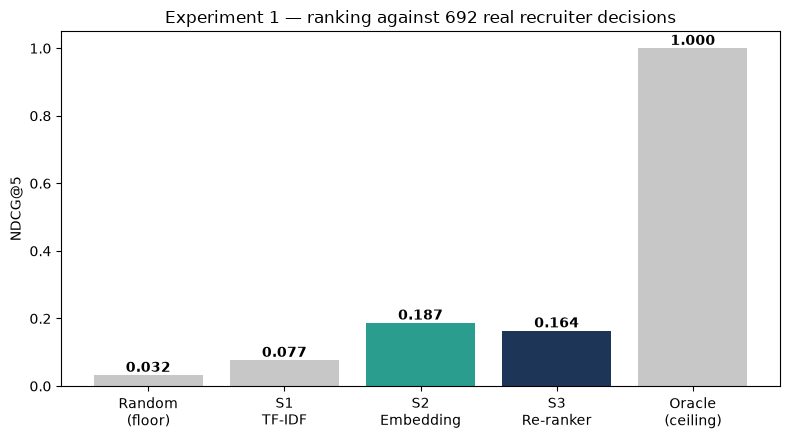

S2 is 2.4x the keyword baseline on NDCG@5


In [2]:
labels = ['Random\n(floor)', 'S1\nTF-IDF', 'S2\nEmbedding', 'S3\nRe-ranker', 'Oracle\n(ceiling)']
vals = [exp1['random_floor']['ndcg@5'],
        ndcg5(exp1, 'S1 TF-IDF keyword'),
        ndcg5(exp1, 'S2 Embedding (production)'),
        ndcg5(exp1, 'S3b Re-ranker (judged only)'),
        exp1['oracle_ceiling']['ndcg@5']]
colors = ['#c7c7c7', '#c7c7c7', '#2a9d8f', '#1d3557', '#c7c7c7']
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, vals, color=colors)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')
ax.set_ylabel('NDCG@5'); ax.set_ylim(0, 1.05)
ax.set_title('Experiment 1 — ranking against 692 real recruiter decisions')
plt.tight_layout(); plt.show()
print(f"S2 is {ndcg5(exp1,'S2 Embedding (production)')/ndcg5(exp1,'S1 TF-IDF keyword'):.1f}x the keyword baseline on NDCG@5")

## 2. Finding 2 — the re-ranking effect reverses with the label source

This is the central contribution. The **same** re-ranker is measured twice. Against the platform's own logs it looks slightly *worse* than S2; against labels the platform never influenced it looks substantially *better*. The direction of the effect flips.

(The two experiments use different candidate-set sizes, so the NDCG values are not comparable across the pair — only the *sign* of each within-experiment difference is.)

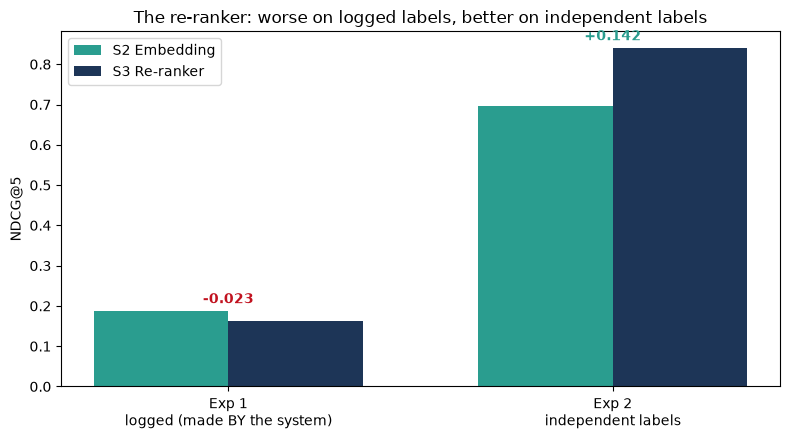

In [3]:
s2_e1, s3_e1 = ndcg5(exp1,'S2 Embedding (production)'), ndcg5(exp1,'S3b Re-ranker (judged only)')
s2_e2, s3_e2 = ndcg5(exp2,'S2 Embedding (production)'), ndcg5(exp2,'S3 + Re-ranker (ours)')
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(2); w = 0.35
ax.bar(x-w/2, [s2_e1, s2_e2], w, label='S2 Embedding', color='#2a9d8f')
ax.bar(x+w/2, [s3_e1, s3_e2], w, label='S3 Re-ranker', color='#1d3557')
ax.set_xticks(x); ax.set_xticklabels(['Exp 1\nlogged (made BY the system)', 'Exp 2\nindependent labels'])
ax.set_ylabel('NDCG@5'); ax.legend()
ax.set_title('The re-ranker: worse on logged labels, better on independent labels')
ax.annotate(f'{s3_e1-s2_e1:+.3f}', (0, max(s2_e1,s3_e1)+0.02), ha='center', color='#c1121f', fontweight='bold')
ax.annotate(f'{s3_e2-s2_e2:+.3f}', (1, max(s2_e2,s3_e2)+0.02), ha='center', color='#2a9d8f', fontweight='bold')
plt.tight_layout(); plt.show()

**Why.** Students can only apply to what the platform showed them, and the platform ranks by cosine similarity, so every logged positive is a high-cosine pair *by construction*. A model trained on those logs can do little but re-learn the incumbent's own score — which is exactly what the feature importances show next.

## 3. Finding 3 — what the re-ranker learns, under each label source

Trained on the platform's own logs, the re-ranker draws most of its gain from `cosine_similarity` — the incumbent's own score. Trained on independent labels, cosine's grip loosens and the structured signals the embedding is blind to (`start_gap_months`, language readiness) take over.

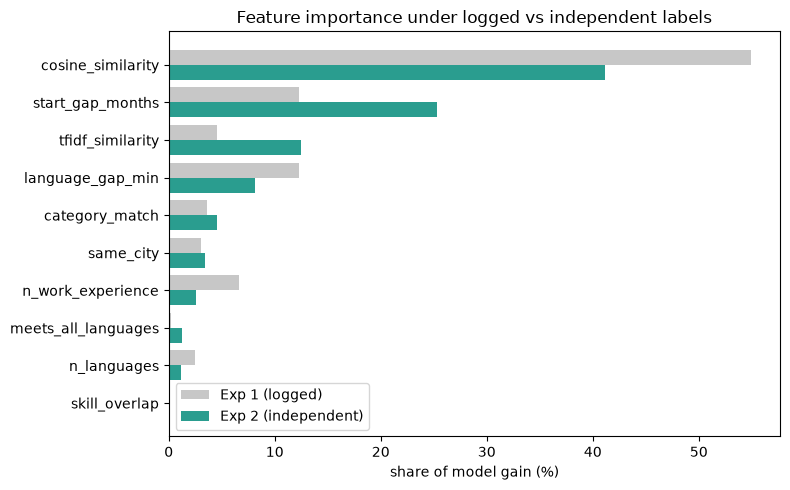

cosine_similarity: 54.9% (logged) -> 41.1% (independent)


In [4]:
fi1 = dict(exp1['feature_importance']['S3b_judged_only'])
fi2 = dict(exp2['feature_importance'])
feats = [f for f,_ in sorted(fi2.items(), key=lambda kv:-kv[1])]
y = np.arange(len(feats))
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(y-0.2, [fi1[f]*100 for f in feats], 0.4, label='Exp 1 (logged)', color='#c7c7c7')
ax.barh(y+0.2, [fi2[f]*100 for f in feats], 0.4, label='Exp 2 (independent)', color='#2a9d8f')
ax.set_yticks(y); ax.set_yticklabels(feats); ax.invert_yaxis()
ax.set_xlabel('share of model gain (%)'); ax.legend()
ax.set_title('Feature importance under logged vs independent labels')
plt.tight_layout(); plt.show()
print(f"cosine_similarity: {fi1['cosine_similarity']*100:.1f}% (logged) -> {fi2['cosine_similarity']*100:.1f}% (independent)")

## 4. The thesis figures

The figures below are the ones that appear in the thesis, rendered at 200 dpi. Each is followed by a note on what it shows.

### Figure 1 — dataset composition
Sizes of the three data files, the balance of recruiter decisions (180 positive / 512 negative), and the spread of German proficiency. The third panel is the signal the embedding discards.

![dataset](../figures/fig6_dataset.png)

### Figure 2 — the blind judge is valid
In Experiment 2, the LLM judge never saw the platform's ranking, yet its mean grade falls monotonically as the platform's rank worsens. It is measuring something real.

![judge validity](../figures/fig7_judge_validity.png)

### Figure 3 — Experiment 1, all systems
NDCG@5 on 692 logged recruiter decisions, between the random floor and the oracle ceiling.

![exp1](../figures/fig1_logged.png)

### Figure 4 — the filters vs real behaviour
Which hard gate would have rejected each of the 692 pairs recruiters actually judged. The city gate alone rejects 89% — students apply across cities.

![filters](../figures/fig5_filter_attrition.png)

### Figure 5 — Experiment 2, all systems
NDCG@5 on exposure-independent labels. Here the re-ranker (S3) leads.

![exp2](../figures/fig2_llm_labels.png)

### Figure 6 — the sign flip (the key figure)
The re-ranking effect measured against the platform's own logs versus against independent labels. The direction reverses. This is the thesis's central finding.

![flip](../figures/fig4_flip.png)

### Figure 7 — feature importance, both experiments
Cosine's dominance loosens once the labels are no longer made by the system under test.

![importance](../figures/fig3_importance.png)

## 5. In one paragraph

Semantic matching clearly beats keyword matching on real hiring decisions. A learned re-ranker built to improve on it *appears* to fail when judged against the platform's own logs and to succeed when judged against independent labels — because the logs were generated by the very system being replaced. The practical lesson reaches beyond apprenticeship matching: a deployed recommender's own interaction data will tend to confirm the deployed recommender.